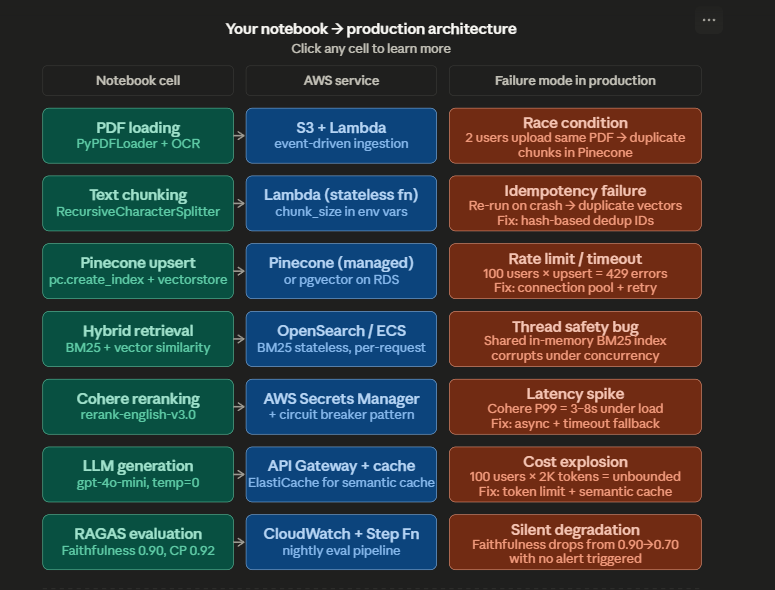

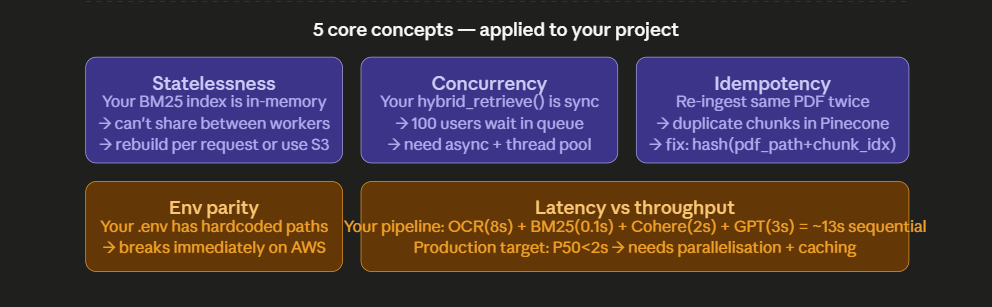

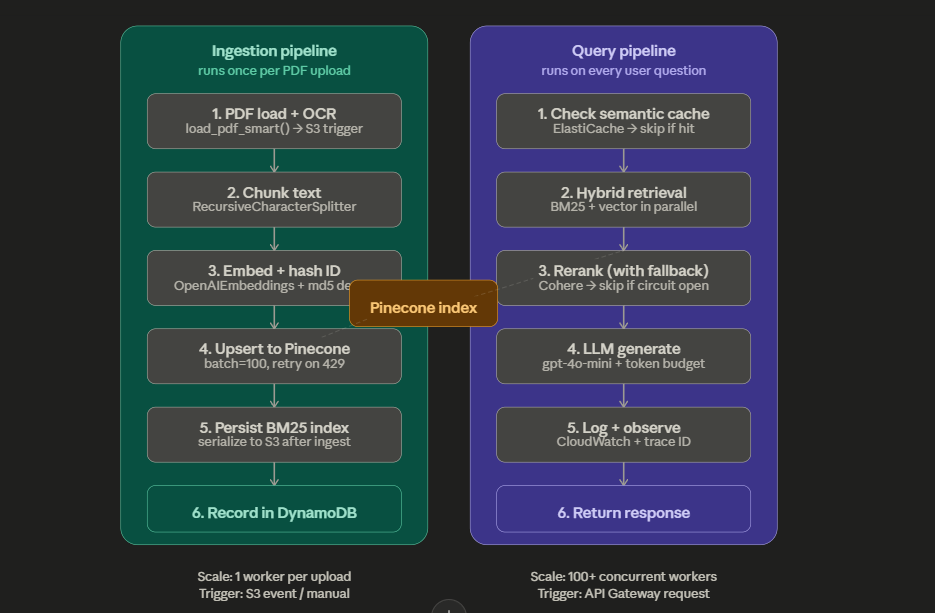

### Circuit Breaker Pattern - Cohere

#### 🧠 Why you need it (your RAG context)

##### In your Legal_Lense pipeline, you depend on:

- OpenAI → LLM
- Cohere → reranking
- Pinecone → vector DB

- Now imagine:

- Cohere API becomes slow or starts failing ❌

##### Without circuit breaker:

- Your system keeps retrying
- Latency increases ⬆️
- Threads get blocked
- Entire pipeline slows down or crashes

##### 🔥 With Circuit Breaker

👉 After repeated failures:

- Stop calling Cohere temporarily
- Use fallback (e.g., skip reranking or use BM25 only)

#### idempotent hash IDs

This is the most important new concept. Your notebook had no deduplication — re-ingesting would create duplicate vectors. The fix is hashing each chunk's content to create a stable ID.

- Concept 1 — Why async matters for your RAG pipeline

Your Hour 2 run_rag_query() is synchronous. This means if 10 users call /query at the same time, requests queue up — user 10 waits for users 1–9 to finish. With async, all 10 pipeline runs start nearly simultaneously and Python switches between them during I/O waits (the Pinecone network call, the OpenAI API call, the Cohere call). Your pipeline is almost entirely I/O bound — the CPU is idle most of the time waiting for API responses. Async turns that idle time into work for other requests.

- The mental model: synchronous is a single cashier serving one customer at a time. Async is one cashier who starts each customer's order, then turns to the next while the coffee machine runs.

- Step 1 — src/api/schemas.py
Pydantic models are the contract between your API and its callers. Every request and response is validated here before any code runs.

- Step 2 — src/api/dependencies.py
This is the most important architectural decision of Hour 3: shared expensive state (the Pinecone connection, the loaded chunks, the embedding model) should be created once when the app starts, not on every request. FastAPI's dependency injection system handles this cleanly.